In [ ]:
#Summary of Data Science Track Unit 4 - Tier 3
#The purpose of this data science project was to analyze the housing price changes in London's boroughs for a twenty year period beginning February,
#2006.  Specifically, the analysis focused on "...which boroughs of London [saw] the greatest increase in housing prices, on average, over the past 
#two decades?  

#To complete the analysis the following methodology was required:
#1) Import modules supporting the mathematical calculation and the tailoring of our expected table and graph
#2) Open and read data from a hosted Excel worksheet
#3) Limit the data to 20 years or 240 months
#4) Convert the data to a table with date as is first attribute and boroughs pricing as the accompanying columns
#5) Sort and perform data checks to ensure the integrity of the data
#6) Analyze the data using a standard compound annual growth rate (CAGR) formula to determine the housing price increases for the boroughs
#7) Filter the data to eliminate non-borough jurisdictions
#8) Display the data as a bar chart/graph
#9) Implement graph overlays to better visualize, contextualize, and label the data
#10) Review the table and visual output to determine which borough had the greatest housing price increase (per CAGR) over the 20-year span

#Based on the methodology and analysis the borough of Walthham Forest had the greatest price increases over the 20-year period ~4.73% CAGR.

            City of London  Barking & Dagenham  Barnet  Bexley   Brent  \
Date                                                                     
2006-02-01          319755              167577  298187  187230  265285   
2006-03-01          321190              166529  298774  187445  266052   
2006-04-01          315730              168790  300399  189189  266283   
2006-05-01          309354              170686  303852  189821  268553   
2006-06-01          301303              173733  305192  191151  272641   
2006-07-01          334232              174958  310189  189332  274517   
2006-08-01          354120              175958  314080  193373  274171   
2006-09-01          372997              175006  318616  194011  274281   
2006-10-01          360778              174842  318034  196526  280637   
2006-11-01          350169              176391  319024  196832  282018   
2006-12-01          361349              179153  322472  198990  284988   
2007-01-01          356576            

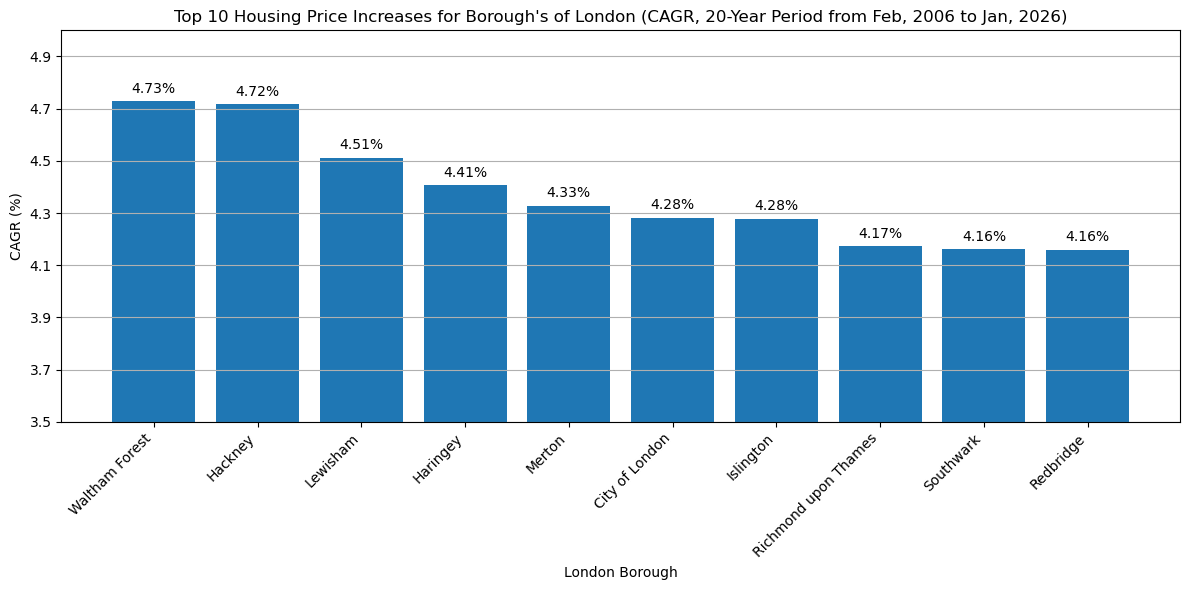

In [2]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

url_LondonHousePrices = "https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index.xls"

# Download the data file with London housing data
response = requests.get(url_LondonHousePrices, headers={"User-Agent": "Mozilla/5.0"})
response.raise_for_status()

with open("london.xls", "wb") as f:
    f.write(response.content)

# Read the Excel sheet with London housing data
properties = pd.read_excel("london.xls", sheet_name="Average price", index_col=None)

# Rename the first column to Date
properties = properties.rename(columns={properties.columns[0]: "Date"})

# Convert Date column to datetime
properties["Date"] = pd.to_datetime(properties["Date"], errors="coerce")

# Error Check: Drop rows where Date is invalid
properties = properties[properties["Date"].notna()]

# Sort by Date column
properties = properties.sort_values("Date")

# Keep 240 months (20 years) of data
properties = properties.tail(240)

# Set Date as the index
properties = properties.set_index("Date")

# Error Check: Ensure numeric in columns
properties = properties.apply(pd.to_numeric, errors='coerce')

# Error Check: Remove columns that are entirely blank
properties = properties.dropna(axis=1, how='all')

# Error Check: Remove values that are <= 0
properties[properties <= 0] = np.nan

# Error Check: Drop columns with any missing values/NaN
properties = properties.dropna(axis=1)

# Error Check: Eliminate columns with NaNs
# OPTIONAL depending on your tolerance:
# properties = properties.dropna(axis=1)

# Error Check: Ensure no duplicate dates
properties = properties[~properties.index.duplicated()]

# Error Check: Confirm monthly continuity
properties = properties.sort_index().asfreq('MS')

# Error Check: Ensure no bad ticks or where date +/-100% month-over-month
pct_change = properties.pct_change(fill_method=None)
outliers = pct_change.abs() > 1

# Display all rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Inspect the cleaned dataset
print(properties)
print()   # blank line between raw data and CAGR output

# Analyze data using standard CAGR formula for 239 periods 
n = len(properties) - 1
cagr = (properties.iloc[-1] / properties.iloc[0]) ** (12 / n) - 1

# Filter data to ensure only boroughs are compared
borough_list = ['Barking & Dagenham','Barnet','Bexley','Brent','Bromley','Camden',
    'Croydon','Ealing','Enfield','Greenwich','Hackney','Hammersmith & Fulham',
    'Haringey','Harrow','Havering','Hillingdon','Hounslow','Islington',
    'Kensington & Chelsea','Kingston upon Thames','Lambeth','Lewisham',
    'Merton','Newham','Redbridge','Richmond upon Thames','Southwark',
    'Sutton','Tower Hamlets','Waltham Forest','Wandsworth','Westminster',
    'City of London']

boroughs = cagr[borough_list]
boroughs_pct = (boroughs * 100).sort_values(ascending=False)

# Suppress Jupyter output Re "dtype: float64"
print(boroughs_pct.to_string())

# Display as per bar chart with formatting included
top_10 = boroughs_pct.head(10)

plt.figure(figsize=(12, 6))

bars = plt.bar(top_10.index, top_10.values)

plt.title("Top 10 Housing Price Increases for Borough's of London (CAGR, 20-Year Period from Feb, 2006 to Jan, 2026)")
plt.xlabel("London Borough")
plt.ylabel("CAGR (%)")

# Format Y-Axis
plt.ylim(3.5, 5.0)
plt.yticks(np.arange(3.5, 5.01, 0.2))

# Format data lables
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}%",
        ha='center',
        va='bottom')

# Format X-Axis
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tight_layout()
plt.show()